In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## A single run

In [2]:
#FOLDER = "04-03-26--14_34_00/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "26-02-26--11_04_41/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

FOLDER = "05-03-26--14_56_45/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"


data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

### Aggregate global accuracy by round

In [3]:
# data = res['users']
# aggregated = agg_global_accuracy_by_round(data)
#
# aggregated

## Multiple runs

In [4]:
# FOLDER = "26-02-26--11_04_41/"
#
# data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# if FOLDER:
#     data_dir = data_dir / FOLDER
#
# runs = load_runs(data_dir)
#
# # Normalize units: wei → ETH, ratio → %
# runs = normalize_runs(runs)
# res = merge_runs(runs)

## Plots

### Plot: plot_accuracy_loss_over_rounds

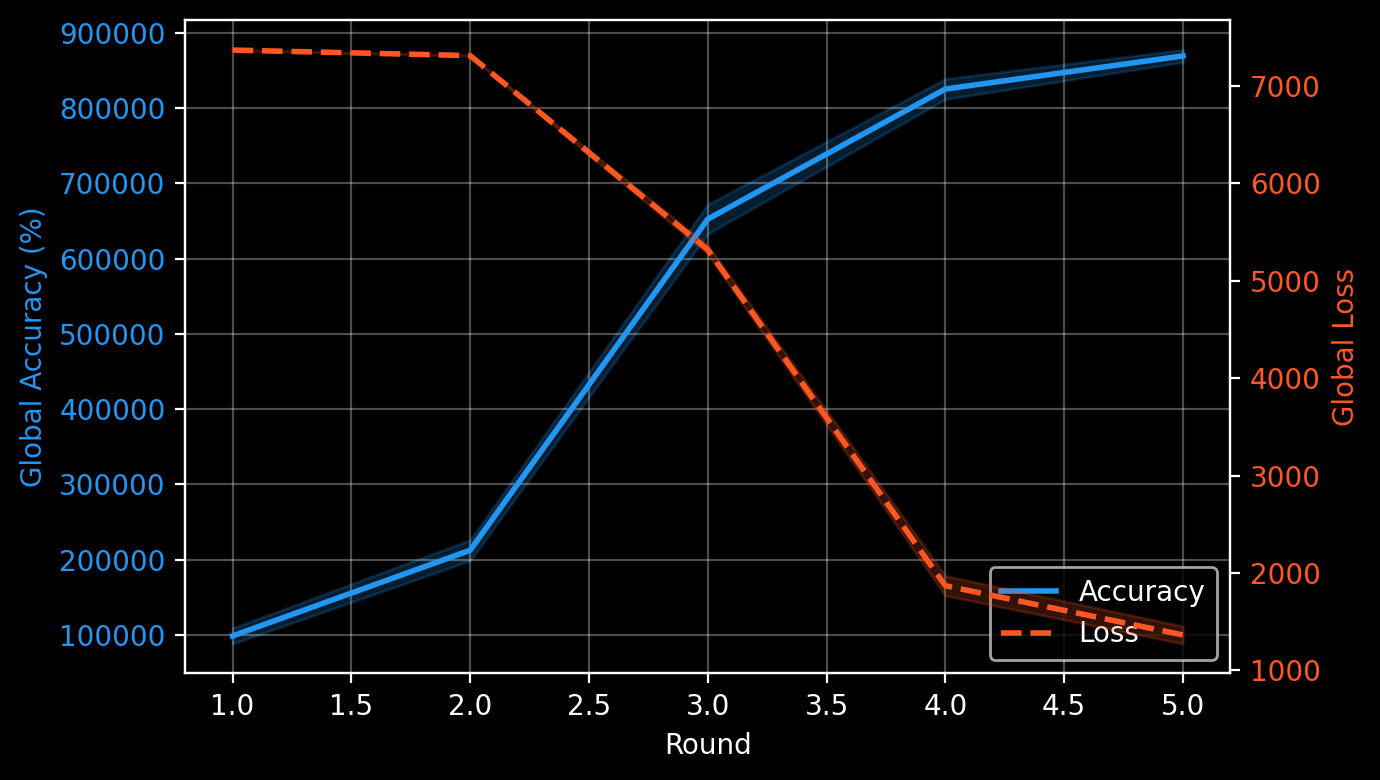

In [5]:
data = res['users']
aggregated = agg_global_accuracy_loss_by_round(data)

fig = plot_accuracy_loss_over_rounds(aggregated) # Assign since it otherwise will plot twice.

#

### Plot: plot_gas_cost_by_tx_type

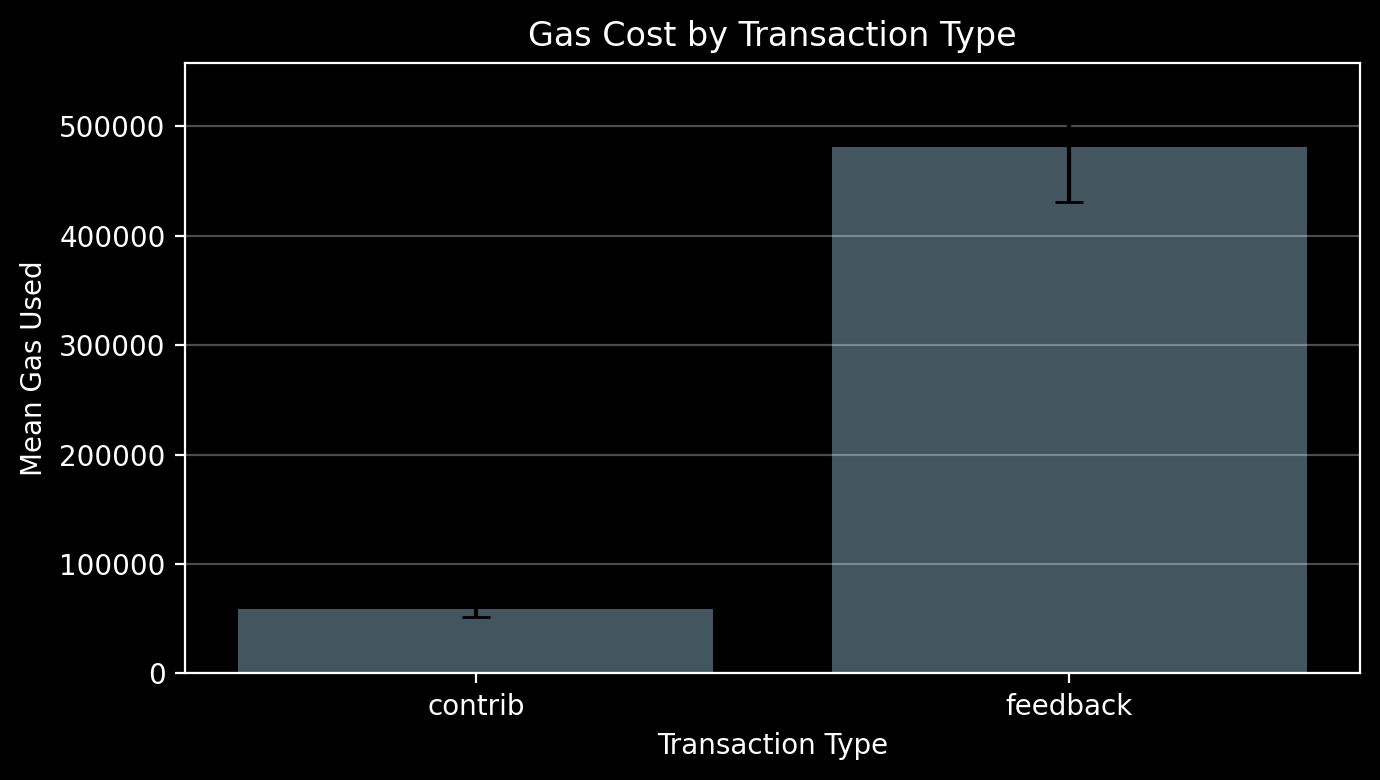

In [6]:
# plot_round_kicked_by_strategy(aggregated)
data = res['receipts']
aggregated = agg_gas_used_by_tx_type(data)
fig = plot_gas_cost_by_tx_type(aggregated)

  ┌──────────────────────────────────────┬──────────────────────────────────┐
  │             Aggregation              │               Plot               │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_global_accuracy_by_round         │ plot_accuracy_loss_over_rounds   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_accuracy_by_strategy             │ plot_strategy_comparison_lines   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_final_round_accuracy_by_strategy │ plot_strategy_comparison_boxplot │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_grs_by_behavior                  │ plot_grs_by_behavior             │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_gas_used_by_tx_type              │ plot_gas_cost_by_tx_type         │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_round_kicked_by_strategy         │ plot_round_kicked_by_strategy    │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_contribution_score_by_behavior   │ (no corresponding plot)          │
  └──────────────────────────────────────┴──────────────────────────────────┘

### Plot: plot_round_kicked_by_strategy

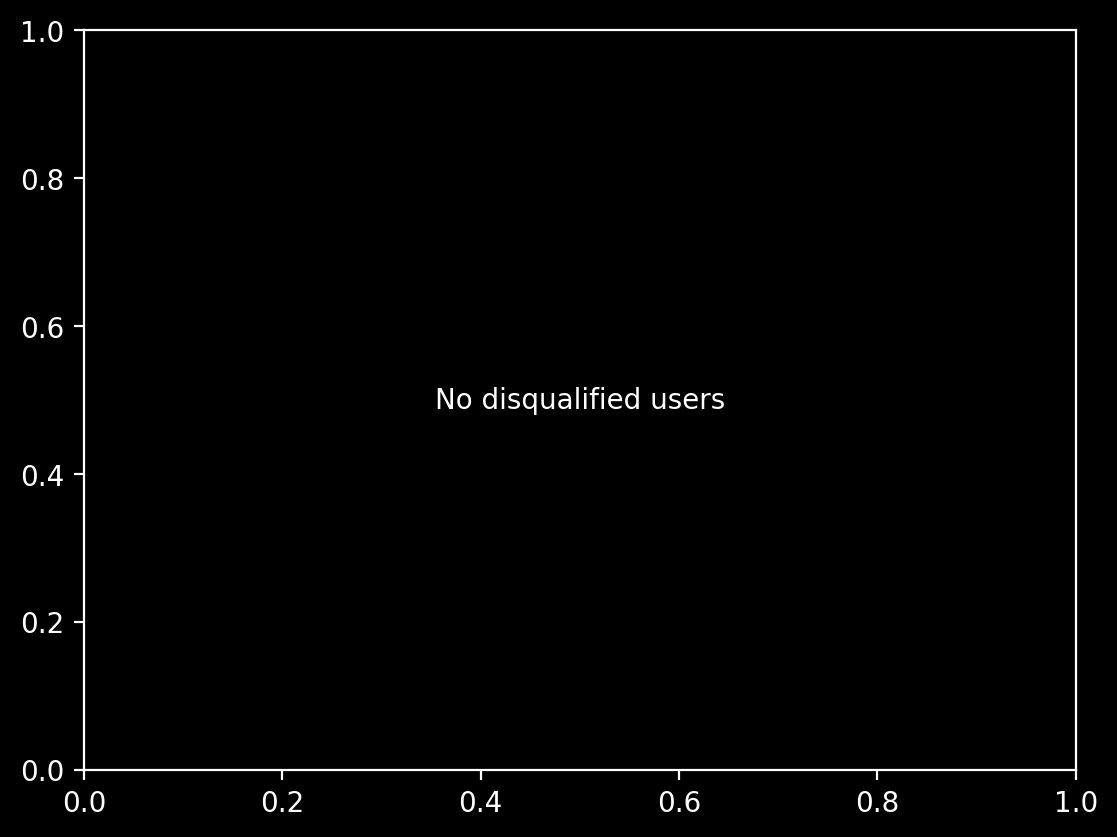

In [7]:
data = res['users']
aggregated = agg_round_kicked_by_strategy(data)
fig = plot_round_kicked_by_strategy(aggregated)

## Plot: Agg. GRS by behavior

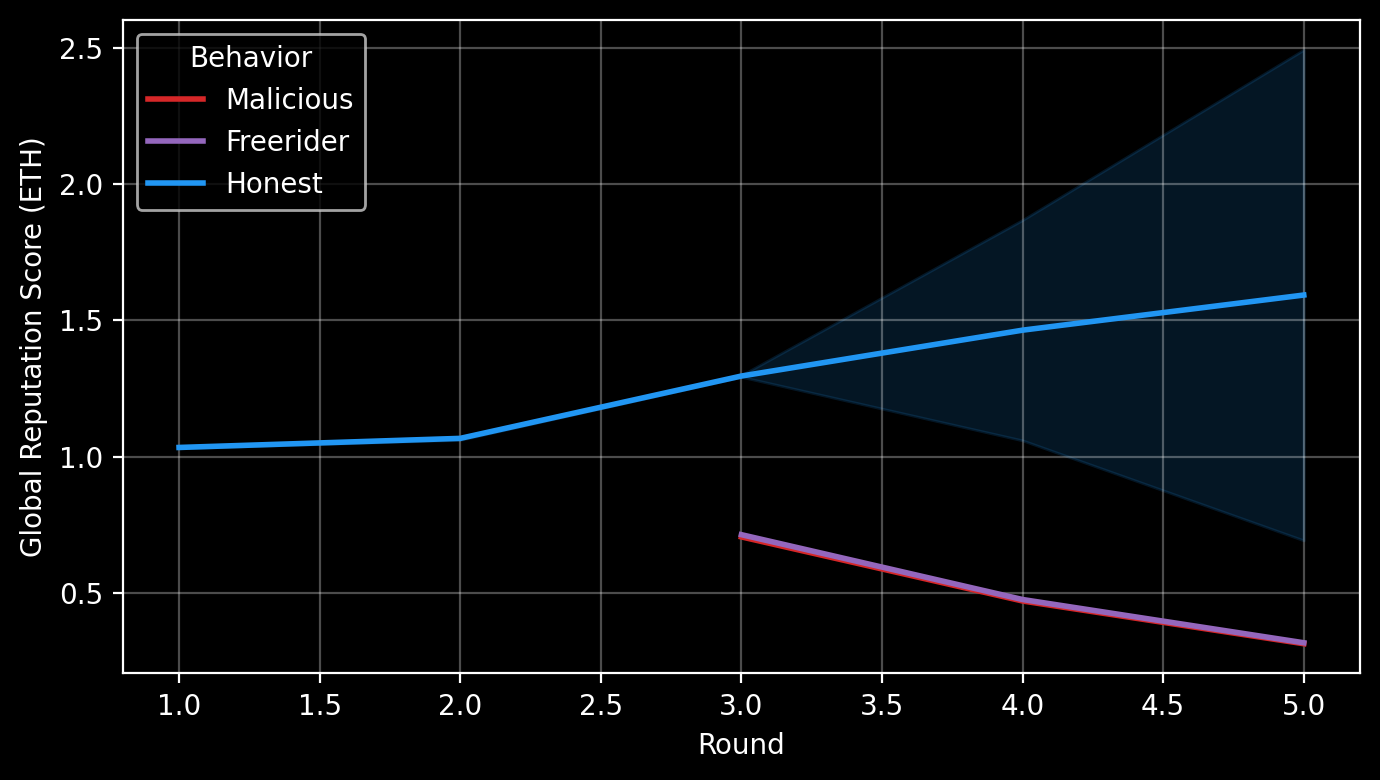

In [8]:
data = res['users']
aggregated = agg_grs_by_behavior(data)
fig = plot_grs_by_behavior(aggregated)


# Why are they not equal at round 3

## Plot: GRS by user

,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds
4,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,4,active,good,bad,88000,7370,1.029028,0.0980,...,3,1.0,3,1.0,False,4,1,1,0,5
10,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,4,active,good,bad,209000,7309,1.057949,0.2155,...,3,1.0,3,1.0,False,4,1,1,0,5
16,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,4,active,bad,bad,655000,5326,0.705299,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
22,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,4,active,bad,bad,837000,1781,0.470200,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
28,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,4,active,bad,bad,879000,1313,0.313466,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5
5,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,5,active,good,freerider,114000,7361,1.035032,0.0980,...,3,1.0,3,1.0,False,4,1,1,0,5
11,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,5,active,good,freerider,231000,7306,1.070217,0.2155,...,3,1.0,3,1.0,False,4,1,1,0,5
17,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,5,active,freerider,freerider,688000,5230,0.713478,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
23,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,5,active,freerider,freerider,842000,1795,0.475652,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
29,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,5,active,freerider,freerider,872000,1326,0.317101,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5


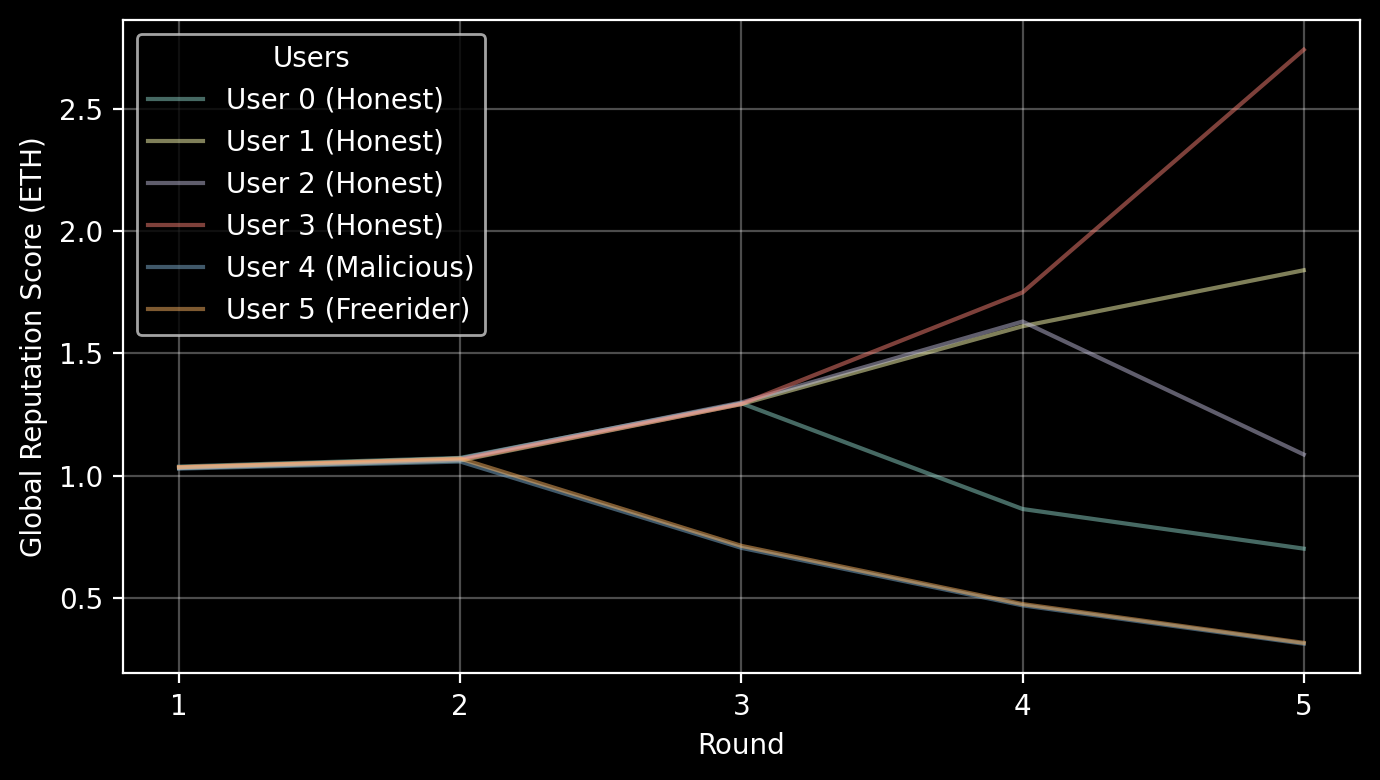

In [9]:
data = res['users']

# data[['grs', 'user_id', 'round']]

vals = grs_by_user(data)

fig = plot_grs_by_user(vals)

data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

In [10]:
data[data['behavior'] == 'good'].groupby('round')[['accuracy', 'grs']].mean()

# data[data['behavior'] == 'good'] & (data['state'] == 'disqualified')

data[(data['behavior'] == 'good') & (data['state'] == 'disqualified')]


,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds


In [11]:
data.sort_values('round')


# data = res['votes']
# data[['giver_id', 'giver_address']].drop_duplicates()

# data[data['user_id'] == 0]


data[data['round'] > 2].sort_values(['user_id', 'round'])

,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds
12,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,0,active,good,good,641000,5336,1.296079,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
18,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,0,active,good,good,808000,1804,0.864053,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
24,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,0,active,good,good,869000,1278,0.702043,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5
13,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,1,active,good,good,631000,5327,1.292904,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
19,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,1,active,good,good,831000,1850,1.610899,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
25,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,1,active,good,good,872000,1324,1.839772,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5
14,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,2,active,good,good,654000,5322,1.299243,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
20,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,2,active,good,good,819000,1944,1.630087,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
26,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,2,active,good,good,869000,1418,1.086724,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5
15,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,3,active,good,good,645000,5372,1.292996,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
